<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/00_%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80_%EB%B3%B5%EC%8A%B5(%EC%9D%98%EB%A3%8C%EB%B9%84%EC%98%88%EC%B8%A1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 실습 목표
- 머신러닝 7과정 복습
- 딥러닝 들어가기 전, 선형회귀 핵심적인 개념들 정리


In [ ]:
# 머신러닝 7과정
# 1. 문제 정의
# 2. 데이터 수집
# 3. 데이터 전처리(결측치, 이상치 처리, 특성 공학(필요 없는 특성들은 탈락시키고, 중요한 특성들은 더 많이 반영시키도록 만듦))
# 4. 탐색적 데이터 분석(EDA)
# 3, 4번 과정은 필요에 의해 왔다갔다할 수 있음
# 5. 모델 선택 및 하이퍼 파라미터 조정
# 6. 모델 학습
# 7. 모델 평가

### 목표
- 선형 회귀 모델을 활용해서 개인의 연간 의료비를 예측해보자

In [ ]:
# 1. 구글 드라이브 마운트
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2. 작업 경로 변경
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


In [ ]:
# 3. 필요 라이브러리 호출(판다스, 넘파이, 파이플랏)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 4. insurance.csv 파일 불러와서 data 변수에 저장
data = pd.read_csv("./data/insurance.csv")

In [ ]:
# 5. 데이터 정보 -> 결측치, dtype 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- age : 나이
- sex : 성별
- bmi : 체질량 지수
- children : 부양 가족 수
- smoker : 흡연 여부
- region : 사는 지역
- charges : 개인 의료비(답데이터)

### EDA : 탐색적 데이터 분석
- EDA 과정에서는 데이터의 특징, 구조, 패턴, 이상치, 변수 간의 관계 등을 분석하고 이해하는 과정
  - 기초 통계 분석 : 평균, 중앙값, 표준편차, 최대, 최소 등 확인
  - 시각화 : 데이터 패턴, 이상치, 경향성 파악
    - 이상치 탐지 : 다른 데이터에 비해 너무 적거나 큰 비정상적인 데이터 식별
    - 결측치 확인 : 누락 데이터 확인
  - 변수 간 관계 파악 : 서로 다른 변수 간 상관관계 분석

In [ ]:
# 1. data 샘플링 -> 앞쪽에 있는 데이터 3개 가져오기
data.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [ ]:
# 2. 문제 데이터, 정답 데이터 분리
# 문제 데이터(X) : charges 제외한 모든 컬럼
# 정답 데이터(y) : charges 컬럼
X = data.loc[:, 'age':'region']
# X = data.drop(columns='charges')
# X = data.drop('charges', axis=1)
y = data['charges']

X.shape, y.shape

((1338, 6), (1338,))

In [ ]:
# 3. 문제 데이터 기초 통계량 확인
# 1) 수치형 데이터 확인
X.describe().T
# count : 전체 데이터 개수
# mean : 평균
# std : 표준편차
# min, max : 최소, 최댓값
# 25% 50% 75% : 사분위수
# 50% : 중앙값, 데이터를 크기 순으로 나열했을 때 딱 중간에 오는 값

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.00,27.00000,39.0,51.00000,64.00
bmi,1338.0,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,1.094918,1.205493,0.00,0.00000,1.0,2.00000,5.00


In [ ]:
# 2) 문자열 데이터 확인
X.describe(include='object').T
# unique : 해당 컬럼에서의 고유값 개수, ex) 성별 : 남/여 -> 2개, 흡연여부 : yes/no -> 2개
# top : 최빈값, 가장 많이 등장하는 값
# freq : 최빈값이 몇 번 등장하는지

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


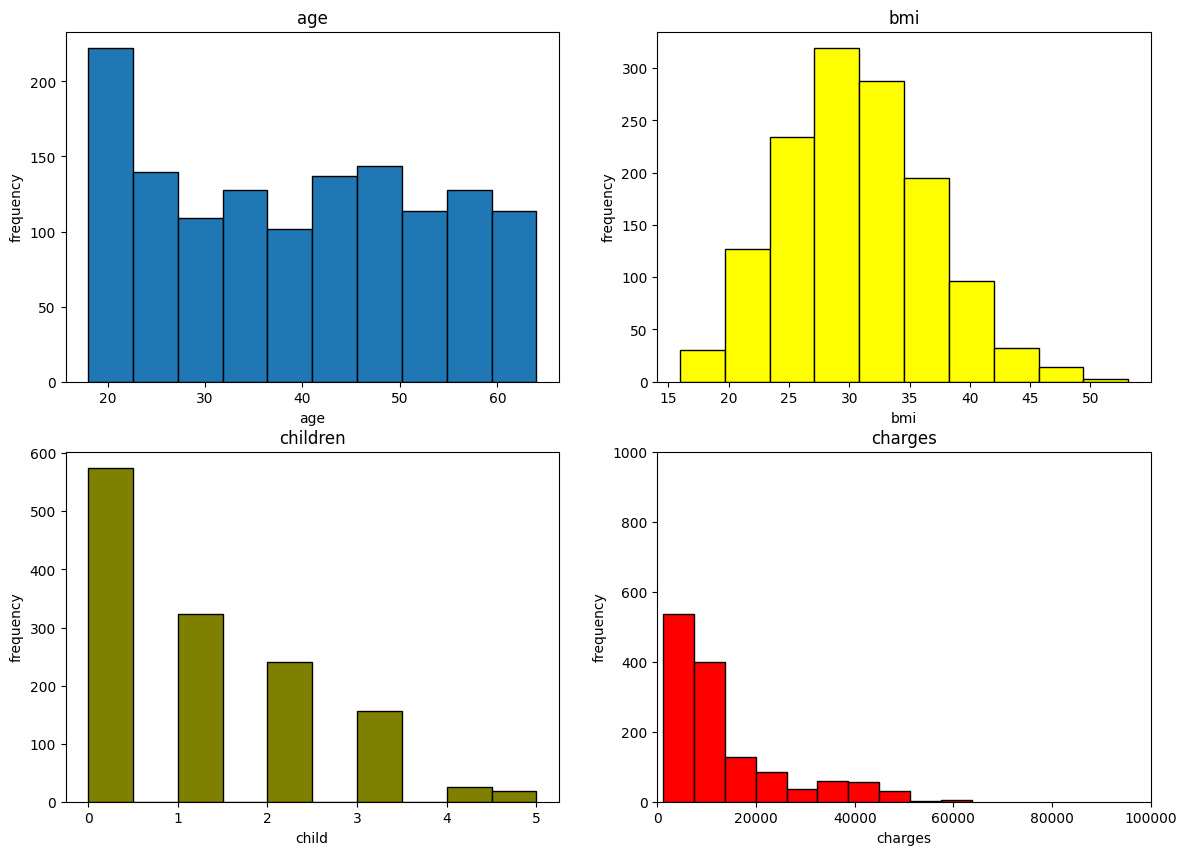

In [ ]:
# 수치형 데이터 시각화
# 수치형 문제데이터 + 타겟 변수 총 4개 그래프를 그릴 예정

# 나이 분포도 그리기
plt.figure(figsize=(14, 10))

plt.subplot(2,2,1) # 도화지를 2행 2열로 나눠서 첫 번째 칸에 그리겠다
plt.hist(data["age"], edgecolor="black") # 히스토그램
plt.xlabel("age")
plt.ylabel("frequency")
plt.title("age")

plt.subplot(2,2,2)
plt.hist(data["bmi"], edgecolor="black", color="yellow") # 히스토그램
plt.xlabel("bmi")
plt.ylabel("frequency")
plt.title("bmi")

plt.subplot(2,2,3)
plt.hist(data["children"], edgecolor="black", color="olive") # 히스토그램
plt.xlabel("child")
plt.ylabel("frequency")
plt.title("children")

plt.subplot(2,2,4)
plt.hist(data["charges"], edgecolor="black", color="red") # 히스토그램
plt.xlabel("charges")
plt.ylabel("frequency")
plt.title("charges")
plt.xlim(0, 100000)
plt.ylim(0, 1000)

plt.show()

# plt.subplot()
# 나이 분포 : 20대 초반을 제외하면 상대적으로 균일한 분포를 가진 데이터
# bmi : 정규분포와 유사한 형태가 보임
# 부양 가족 수 분포 : 20대 데이터가 많기 때문에 0명이 가장 많고, 숫자가 커질수록 적은 분포를 가지고 있음
# 의료비 분포 : 오른쪽으로 꼬리가 긴 형태(왼쪽으로 치우친 형태)

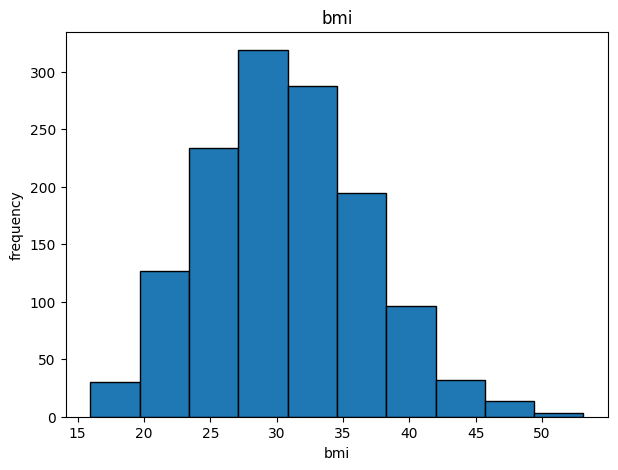

In [ ]:
# bmi 분포도 그리기
plt.figure(figsize=(7, 5))

plt.hist(data["bmi"], edgecolor="black") # 히스토그램
plt.xlabel("bmi")
plt.ylabel("frequency")
plt.title("bmi")

plt.show()

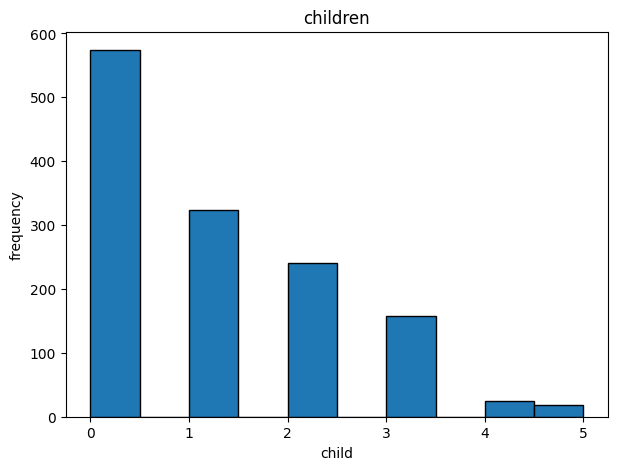

In [ ]:
# chiledrn 분포도 그리기
plt.figure(figsize=(7, 5))

plt.hist(data["children"], edgecolor="black") # 히스토그램
plt.xlabel("child")
plt.ylabel("frequency")
plt.title("children")

plt.show()

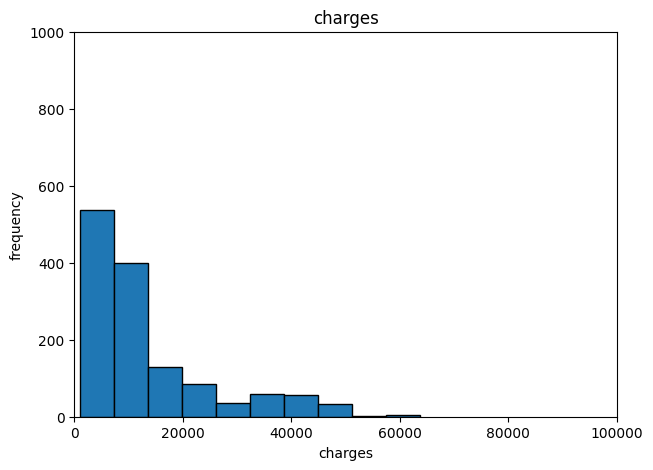

In [ ]:
# charges 분포도 그리기
plt.figure(figsize=(7, 5))

plt.hist(data["charges"], edgecolor="black") # 히스토그램
plt.xlabel("charges")
plt.ylabel("frequency")
plt.title("charges")
plt.xlim(0, 100000)
plt.ylim(0, 1000)

plt.show()

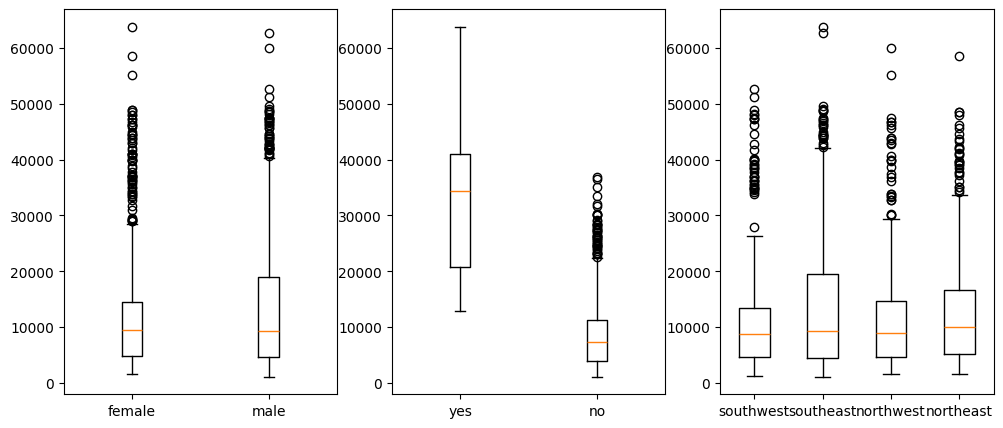

In [ ]:
# boxplot을 활용해서 범주형 데이터 시각화
# 1. 성별에 따른 의료비용 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1,3,1)
plt.boxplot([
    data[data["sex"] == "female"]["charges"], # 여성의 의료비용
    data[data["sex"] == "male"]["charges"]],  # 남성의 의료비용
    tick_labels=["female", "male"])

# 흡연 여부별 의료비용
plt.subplot(1,3,2)
plt.boxplot([
    data[data["smoker"] == "yes"]["charges"], # 여성의 의료비용
    data[data["smoker"] == "no"]["charges"]],  # 남성의 의료비용
    tick_labels=["yes", "no"])

# 지역별 의료비용
plt.subplot(1,3,3)
plt.boxplot([
    data[data["region"] == "southwest"]["charges"], # 여성의 의료비용
    data[data["region"] == "southeast"]["charges"],
    data[data["region"] == "northwest"]["charges"],
    data[data["region"] == "northeast"]["charges"]],  # 남성의 의료비용
    tick_labels=["southwest", "southeast", "northwest", "northeast"])

plt.show()
# 성별, 지역별 : 최저값, 중앙값 확인시 육안으로는 비슷한 값을 띠고 있음
# 흡연 여부 : 흡연 여부에 따라서 큰 차이가 보임 → 흡연자의 의료비용이 상대적으로 높음

In [ ]:
data["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
# 데이터 전처리
# object 타입의 컬럼이 3개 -> 수치형 데이터로 변환
# 인코딩 : 문자열 형태의 데이터를 컴퓨터가 해석할 수 있는 수치형 자료로 변환하는 과정
# 1. 원핫 인코딩
# - 범주형 데이터의 고유값별로 컬럼을 만듦 -> 해당 컬럼의 값이면 1, 그렇지 않으면 0
# 과일 컬럼 : apple, banana -> 과일_apple, 과일_banana 컬럼 생성
# apple -> [1, 0], banana -> [0, 1]

# 장점 : 잘못 해석될 가능성이 없음
# 단점 : 고유값의 개수가 많으면 처리해야 되는 데이터의 양이 엄청 늘어남

# 2. 레이블 인코딩
# - 범주별로 숫자 부여
# 과일 컬럼 : apple(0), banana(1)
# apple -> 0, banana -> 1

# 장점 : 고유값의 개수가 많아져도 컬럼 한 개만 사용해 변환 가능
# 단점 : 잘못 해석될 가능성이 있음

In [ ]:
# 1. 문제 데이터 원핫 인코딩(pd.get_dummies) -> X_oh
X_oh = pd.get_dummies(X, dtype=int)
X_oh.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,0
2,28,33.000,3,0,1,1,0,0,0,1,0
3,33,22.705,0,0,1,1,0,0,1,0,0
4,32,28.880,0,0,1,1,0,0,1,0,0


In [ ]:
# 2. 훈련/테스트 데이터 분리
# 비율 7:3, 난수 18
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_oh, y,
    test_size=0.3,   # 7:3 비율
    random_state=18  # 난수 고정
)

In [ ]:
# 2-1) X_train, y_train 모양 확인
print(X_train.shape)
print(y_train.shape)
# 2-2) X_test, y_test 모양 확인
print(X_test.shape)
print(y_test.shape)

(936, 11)
(936,)
(402, 11)
(402,)


### 모델링
- Linear Regression, SGD Regression

In [ ]:
# 1. Linear Regression 사용 : 수학적 공식을 이용한 해석 모델
# 1) 모델 import
from sklearn.linear_model import LinearRegression
# 2) 모델 객체 생성 -> linear_model
linear_model = LinearRegression()
# 3) 모델 학습
linear_model.fit(X_train, y_train)
# 4) 모델 평가 -> score
linear_model.score(X_train, y_train), linear_model.score(X_test, y_test)
# y_pred = linear_model.predict(X_test)

# # from sklearn.metrics import r2_score

# # r2_score(y_test, y_pred)

(0.7408744098887392, 0.7678203103891313)

In [ ]:
# 경사하강법을 활용한 SGDRegressor
from sklearn.linear_model import SGDRegressor

# 경사하강법 : 오차가 최소가 되는 a, b를 기울기를 통해 찾아가는 과정
# 학습률 : 조정값 반영 정도

sgd_model = SGDRegressor(eta0 = 0.01, verbose=1)
# 학습률 0.01,학습 과정 시각화

sgd_model.fit(X_train, y_train)

-- Epoch 1
Norm: 85150534595.28, NNZs: 11, Bias: -4954009598.533537, T: 936, Avg. loss: 7019033716026534912851968.000000
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 69222014485.22, NNZs: 11, Bias: -1839658138.785347, T: 1872, Avg. loss: 2780273208629777691312128.000000
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 116555926058.94, NNZs: 11, Bias: 1907585409.633150, T: 2808, Avg. loss: 1942400068703877179899904.000000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 57997002877.01, NNZs: 11, Bias: 11100009304.389299, T: 3744, Avg. loss: 1496457557185454063747072.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 103639926912.03, NNZs: 11, Bias: 13869300619.132626, T: 4680, Avg. loss: 1260482321666707191496704.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 79502394212.34, NNZs: 11, Bias: 16994540684.762354, T: 5616, Avg. loss: 1110094637166261633548288.000000
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 78788061226.46, NNZs: 11, Bias: 101276480

SGDRegressor(verbose=1)

In [ ]:
sgd_model.score(X_train, y_train), sgd_model.score(X_test, y_test)

(-13432537395.23906, -11020933774.012487)

### 모델 성능 개선
1. 특성 확장
2. 스케일링
3. 규제

### 1. 특성 확장
- 데이터 전처리 과정 중 하나
- 성능이 안 나오는 이유가 특성이 너무 적어서일 수 있기 때문에 특성 확장(특성곱)을 진행해보자!
- 특성곱 : 특성(컬럼, 문제)들끼리 곱해서 새로운 특성을 만드는 것

In [ ]:
# 모든 컬럼을 다른 컬럼들과 다 곱해서 새로운 특성을 만들자!
col = X_oh.columns
col

Index(['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no',
       'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [ ]:
# 반복문을 통해 전체 컬럼을 순회하면서 다른 컬럼들과 곱해주자
for i in range(len(col)) :
  for j in range(i, len(col)) : # 앞서 곱해준 컬럼과는 다시 계산할 필요가 없기 때문에 range의 시작을 i로 설정
    # X_oh df에 새로운 컬럼을 추가해서 특성곱 결과 저장
    X_oh[col[i] + "*" + col[j]] = X_oh[col[i]] * X_oh[col[j]]

In [ ]:
X_oh.shape

(1338, 77)

In [ ]:
X_oh.tail()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,...,region_northeast*region_northeast,region_northeast*region_northwest,region_northeast*region_southeast,region_northeast*region_southwest,region_northwest*region_northwest,region_northwest*region_southeast,region_northwest*region_southwest,region_southeast*region_southeast,region_southeast*region_southwest,region_southwest*region_southwest
1333,50,30.97,3,0,1,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
1334,18,31.92,0,1,0,1,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
1335,18,36.85,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1336,21,25.80,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1337,61,29.07,0,1,0,0,1,0,1,0,...,0,0,0,0,1,0,0,0,0,0


### 2. 데이터 스케일링
- 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 데이터 전처리 과정
- 모든 특성이 모델에 미치는 영향력을 균형 있게 만들어줌
- 거리를 활용하는 모델 + 경사하강법을 활용하는 모델의 경우 성능에 직접적인 영향을 줌
- Standard Scaler, MinMax Scaler 등
- 주의 사항 : 데이터 전처리 마지막에 사용
  - 훈련 데이터/테스트 데이터에 동일한 스케일러를 사용
  - 결측치가 없는 상태에서 사용(이상치는 있어도 됨)

In [ ]:
# 스케일러 도구 불러오기
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler() # 스케일러 객체 생성

scaler.fit(X_oh)

MinMaxScaler()

In [ ]:
X_oh

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,...,region_northeast*region_northeast,region_northeast*region_northwest,region_northeast*region_southeast,region_northeast*region_southwest,region_northwest*region_northwest,region_northwest*region_southeast,region_northwest*region_southwest,region_southeast*region_southeast,region_southeast*region_southwest,region_southwest*region_southwest
0,19,27.900,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,18,33.770,1,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,28,33.000,3,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,33,22.705,0,0,1,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,32,28.880,0,0,1,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,1,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
1334,18,31.920,0,1,0,1,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
1335,18,36.850,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1336,21,25.800,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# 변환
X_trans = scaler.transform(X_oh)
X_trans

array([[0.02173913, 0.3212268 , 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.47914985, 0.2       , ..., 1.        , 0.        ,
        0.        ],
       [0.2173913 , 0.45843422, 0.6       , ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.56201238, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.06521739, 0.26472962, 0.        , ..., 0.        , 0.        ,
        1.        ],
       [0.93478261, 0.35270379, 0.        , ..., 0.        , 0.        ,
        0.        ]])

### 모델링
1. train, test 데이터 분리(7:3, 랜덤 시드 25)
2. linear Regression, SGD 모델 객체 생성 및 학습
3. 성능 평가(train, test)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_oh, y,
    test_size=0.3,   # 7:3 비율
    random_state=25  # 난수 고정
)

scaler = MinMaxScaler() # 스케일러 객체 생성

scaler.fit(X_train)

# 변환
X_train_trans = scaler.transform(X_train)
X_test_trans = scaler.transform(X_test)

from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_trans, y_train)
linear_model.score(X_train_trans, y_train), linear_model.score(X_test_trans, y_test)

(0.8551970497302117, 0.8241212256935264)

In [ ]:
# 경사하강법을 활용한 SGDRegressor
from sklearn.linear_model import SGDRegressor

# 경사하강법 : 오차가 최소가 되는 a, b를 기울기를 통해 찾아가는 과정
# 학습률 : 조정값 반영 정도

sgd_model = SGDRegressor(eta0 = 0.01, random_state=25)
# 학습률 0.01

sgd_model.fit(X_train_trans, y_train)

sgd_model.score(X_train_trans, y_train), sgd_model.score(X_test_trans, y_test)

(0.826313073958822, 0.8033577764204648)

### 규제 적용 모델
- 선형 모델의 단점을 보완하기 위해 등장한 모델
  - 모델이 잘못됐을 경우 수정할 수 있는 방법이 많이 없음
  (과대적합 됐을 때 조정이 어려움)
    - 규제를 가해서 단점을 해소
    - 선형 회귀 + L1 규제 : Lasso(불필요한 특성의 가중치를 0으로 만들어서 삭제)
    - 선형 회귀 + L2 규제 : Ridge(불필요한 특성의 가중치를 0에 가깝게 줄임)
    - 규제 : 선형 모델의 가중치(w)에 영향을 주는 것 -> 모델에 개입

In [ ]:
from sklearn.linear_model import Lasso, Ridge

In [ ]:
# L2 규제 (Ridge활용)
def ridge_alpha(alpha) :
  # 모델 객체 생성
  # alpha = 규제강도, 클수록 강한 조정
  ridge = Ridge(alpha=alpha)
  # 학습
  ridge.fit(X_train, y_train)
  # 평가
  print("훈련용 점수 :", ridge.score(X_train, y_train))
  print("테스트용 점수 :", ridge.score(X_test, y_test))

In [ ]:
# L1 규제 (Lasso활용)
def lasso_alpha(alpha) :
  # 모델 객체 생성
  # alpha = 규제강도, 클수록 강한 조정
  lasso = Lasso(alpha=alpha, max_iter=100000)
  # 학습
  lasso.fit(X_train, y_train)
  # 평가
  print("훈련용 점수 :", lasso.score(X_train, y_train))
  print("테스트용 점수 :", lasso.score(X_test, y_test))

  print("사용된 특성의 수 :", np.sum(lasso.coef_!=0))

In [ ]:
ridge_alpha(0.1)

훈련용 점수 : 0.8551966772711104
테스트용 점수 : 0.8241924855661367


In [ ]:
ridge_alpha(0.001)

훈련용 점수 : 0.8551970496925931
테스트용 점수 : 0.8241219470958294


In [ ]:
ridge_alpha(10)

훈련용 점수 : 0.8535138107012921
테스트용 점수 : 0.8265849234498455


In [ ]:
# alpha 값을 증가 -> 규제를 늘리겠다 -> 모델이 복잡해지는 것을 막을 수 있음(과대적합일 때 사용)
# alpha 값을 감소 -> 규제를 줄이겠다 -> 모델이 단순해지는 것을 막겠다(과소적합일 때 사용)

# ridge 모델을 규제를 하든, 안 하든 모든 컬럼을 사용하게 되어 있음
# 전체 컬럼이 고루고루 중요할 때 사용

In [ ]:
lasso_alpha(0.1)

훈련용 점수 : 0.855196986598674
테스트용 점수 : 0.8241621160411816
사용된 특성의 수 : 51


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.757e+09, tolerance: 1.363e+07
  model = cd_fast.enet_coordinate_descent(


In [ ]:
lasso_alpha(2)

훈련용 점수 : 0.8551717615772985
테스트용 점수 : 0.8249001144147967
사용된 특성의 수 : 45


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.500e+09, tolerance: 1.363e+07
  model = cd_fast.enet_coordinate_descent(


In [ ]:
lasso_alpha(5)

훈련용 점수 : 0.8550436874933035
테스트용 점수 : 0.8259354807615703
사용된 특성의 수 : 42


In [ ]:
# 규제를 늘릴수록 사용한 특성의 개수가 줄어듦
# lasso 모델은 특정 특성이 중요하고 나머지 특성의 중요도가 현저히 낮을 때 사용

### 정리
1. 선형 회귀
> y = wx + b
- 하나의 직선을 가지고 데이터의 분포를 설명하고자 하는 모델

2. 손실 함수(Loss Function)
- 실제값과 예측값의 차이 계산
- MSE(Mean Squared Error), Cross entropy

3. 경사하강법(Gradient Descent)
- loss를 줄이는 방향으로 w, b를 업데이트

딥러닝 모델 = 선형결합 + 비선형함수